# Modelos avanzados de predicción de volatilidad — comparación y análisis de overfitting

**Objetivo de este notebook:** comparar `Ridge`, `RandomForest`, `GradientBoosting`,
`XGBoost`, `LightGBM` y una red **LSTM**, con foco en tres preguntas, no en
elegir "el ganador" a ciegas:

1. **¿Qué tanto sobreajusta (overfitting) cada modelo?** — medido como la
   brecha entre error de entrenamiento y error de prueba, no solo el error
   de prueba solo.
2. **¿Qué tan bien generaliza en términos clásicos?** — RMSE, R² y **R²
   ajustado** (penaliza modelos con más variables que no aportan proporcionalmente).
3. **¿Qué variables realmente influyen en la predicción?** — importancia
   nativa de cada modelo + *permutation importance* (más robusta, agnóstica
   al modelo) + un experimento concreto de **eliminar las variables de
   menor aporte** y ver si el modelo se simplifica sin perder desempeño.

**Entrada:** `GET /features/history` del **Data Service** (mismo contrato
que el notebook de exploración inicial — RNF17: sin importar código de otro
servicio).

**Fuera de alcance aquí:** selección final del modelo de producción y su
exportación al Model Registry — eso se decide después de leer los
resultados de este notebook, no se hardcodea antes.


## Metodología de evaluación

- **Walk-Forward Validation con ventana expansiva** para los modelos
  clásicos: el conjunto de entrenamiento nunca se reduce entre folds, y el
  conjunto de prueba de cada fold es siempre el bloque de datos
  inmediatamente posterior — nunca se valida con información del futuro
  (mismo principio de RF03, aplicado también a la validación, no solo al
  feature engineering).
- **RMSE** (error en las mismas unidades que el target — log-range),
  **R²** y **R² ajustado** (`1 - (1-R²)·(n-1)/(n-p-1)`, penaliza agregar
  variables que no compensan con más poder predictivo) se reportan como el
  **promedio entre folds**, no de un solo split — un modelo que solo se ve
  bien en un fold particular no debe ganar.
- **Brecha de overfitting** = `RMSE_test − RMSE_train` promedio. Cercana a
  cero = el modelo generaliza; muy positiva = memoriza el set de
  entrenamiento y falla en datos nuevos.
- La **LSTM** se evalúa aparte (arquitectura distinta, requiere secuencias)
  con un split cronológico train/val/test simple, usando *early stopping*
  sobre la pérdida de validación como su propio mecanismo anti-overfitting.


In [1]:
# Imports. xgboost/lightgbm y tensorflow son las únicas dependencias
# nuevas respecto al notebook de exploración inicial.
import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import tensorflow as tf
from tensorflow import keras

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)


I0000 00:00:1784947184.378395   99756 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784947184.379113   99756 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784947184.882809   99756 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784947186.500700   99756 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## 1. Carga de datos vía la API del Data Service

In [2]:
DATA_SERVICE_URL = "http://localhost:8000"  # ajusta si tu Data Service corre en otro host/puerto
PAIR_CODE = "SP500_VIX"  # cambia a "NASDAQ_VXN" para correr el mismo análisis sobre ese par

EXPECTED_FEATURE_COLUMNS = [
    "main_log_return", "main_log_range", "main_body_log",
    "main_upper_wick_log", "main_lower_wick_log",
    "main_vol_5d", "main_vol_10d",
    "vol_idx_log_close", "vol_idx_log_range", "vol_idx_log_return",
    "day_of_week", "target_range_next_day",
]

response = requests.get(f"{DATA_SERVICE_URL}/features/history", params={"pair_code": PAIR_CODE}, timeout=30)
response.raise_for_status()
rows = response.json()
assert rows, f"El Data Service no devolvió filas para {PAIR_CODE}."

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

missing = set(EXPECTED_FEATURE_COLUMNS) - set(df.columns)
assert not missing, f"Faltan columnas esperadas del esquema: {missing}"
versions = df["schema_version"].unique()
assert len(versions) == 1, f"Se mezclaron filas de más de una versión de esquema: {versions}"

# Igual que en el notebook de exploración: nos quedamos solo con las
# columnas de trabajo, indexadas por fecha.
df = df.set_index("date")[EXPECTED_FEATURE_COLUMNS]

FEATURE_COLS = [c for c in EXPECTED_FEATURE_COLUMNS if c != "target_range_next_day"]

print(f"Par:                {PAIR_CODE}")
print(f"Filas:              {len(df)}")
print(f"Rango de fechas:    {df.index.min().date()} → {df.index.max().date()}")
print(f"Versión de esquema: {versions[0]}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
df.head()


Par:                SP500_VIX
Filas:              5411
Rango de fechas:    2005-01-18 → 2026-07-22
Versión de esquema: v1
Features (11): ['main_log_return', 'main_log_range', 'main_body_log', 'main_upper_wick_log', 'main_lower_wick_log', 'main_vol_5d', 'main_vol_10d', 'vol_idx_log_close', 'vol_idx_log_range', 'vol_idx_log_return', 'day_of_week']


,main_log_return,main_log_range,main_body_log,main_upper_wick_log,main_lower_wick_log,main_vol_5d,main_vol_10d,vol_idx_log_close,vol_idx_log_range,vol_idx_log_return,day_of_week,target_range_next_day
date,,,,,,,,,,,,
2005-01-18,0.009628,0.013367,0.009628,0.000000,0.003738,0.007942,0.006923,2.523326,0.066822,0.003213,1,0.009721
2005-01-19,-0.009535,0.009721,-0.009535,0.000000,0.000186,0.008803,0.006550,2.578701,0.062472,0.055375,2,0.009508
2005-01-20,-0.007813,0.009508,-0.007813,0.000000,0.001694,0.009138,0.006911,2.626840,0.060625,0.048140,3,0.009909
2005-01-21,-0.006435,0.009909,-0.006435,0.003431,0.000043,0.008783,0.006953,2.664447,0.076132,0.037606,4,0.007943
2005-01-24,-0.003534,0.007943,-0.003534,0.004409,0.000000,0.007681,0.006976,2.684440,0.040116,0.019994,0,0.009025


## 2. Funciones de evaluación (RMSE, R² ajustado, Walk-Forward Validation)

In [3]:
def rmse(y_true, y_pred) -> float:
    """Root Mean Squared Error, en las mismas unidades que el target."""
    return mean_squared_error(y_true, y_pred) ** 0.5


def adjusted_r2(r2: float, n: int, p: int) -> float:
    """R² ajustado: penaliza modelos con más variables (p) que no aportan
    proporcionalmente más poder predictivo. Si n-p-1 <= 0 (muy pocas
    observaciones para tantas variables) devuelve NaN en vez de un valor
    matemáticamente indefinido."""
    if n - p - 1 <= 0:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


def walk_forward_validate(build_model, X, y, n_splits: int = 5, min_train_frac: float = 0.5) -> pd.DataFrame:
    """Walk-Forward Validation con ventana expansiva.

    En cada fold, el conjunto de entrenamiento crece (nunca se reduce) y el
    conjunto de prueba es siempre el bloque de datos inmediatamente
    posterior — el mismo principio anti-data-leakage de RF03, aplicado a la
    validación del modelo y no solo al cálculo de features.

    `build_model` es una función sin argumentos que devuelve un modelo
    nuevo (sin entrenar) — así cada fold entrena desde cero, sin arrastrar
    estado de folds anteriores.
    """
    n = len(X)
    min_train = int(n * min_train_frac)
    fold_size = (n - min_train) // n_splits

    records = []
    for fold in range(1, n_splits + 1):
        train_end = min_train + fold_size * (fold - 1)
        test_end = min_train + fold_size * fold if fold < n_splits else n
        if test_end <= train_end:
            continue

        X_train, y_train = X[:train_end], y[:train_end]
        X_test, y_test = X[train_end:test_end], y[train_end:test_end]

        model = build_model()
        model.fit(X_train, y_train)
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        p = X.shape[1]
        test_r2 = r2_score(y_test, test_pred)
        records.append({
            "fold": fold,
            "n_train": len(y_train),
            "n_test": len(y_test),
            "train_rmse": rmse(y_train, train_pred),
            "test_rmse": rmse(y_test, test_pred),
            "train_r2": r2_score(y_train, train_pred),
            "test_r2": test_r2,
            "test_r2_adj": adjusted_r2(test_r2, len(y_test), p),
        })
    return pd.DataFrame(records)


X = df[FEATURE_COLS].values
y = df["target_range_next_day"].values
print(f"X: {X.shape}   y: {y.shape}")


X: (5411, 11)   y: (5411,)


## 3. Modelos clásicos: definición con regularización explícita

Cada modelo se define con hiperparámetros pensados para **prevenir
overfitting desde el diseño**, no solo para maximizar ajuste:

- **Ridge**: la regularización L2 (`alpha`) es su mecanismo completo
  anti-overfitting; se estandarizan las features primero porque Ridge es
  sensible a la escala (sin esto, features con rangos numéricos más
  grandes dominan artificialmente el coeficiente).
- **RandomForest**: `max_depth` y `min_samples_leaf` limitan qué tan
  específico puede volverse cada árbol individual — la lección de este
  proyecto es que sin este límite el bosque memoriza ruido en vez de
  aprender señal (más notorio en NASDAQ que en SP500).
- **GradientBoosting / XGBoost / LightGBM**: combinan árboles poco
  profundos (`max_depth` bajo), `learning_rate` conservador, y
  `subsample`/`colsample_bytree` < 1 (cada árbol ve una submuestra de
  filas/columnas, reduciendo correlación entre árboles y por lo tanto
  overfitting del ensamble).


In [4]:
MODEL_BUILDERS = {
    "Ridge": lambda: make_pipeline(
        StandardScaler(), Ridge(alpha=1.0, random_state=RANDOM_STATE)
    ),
    "RandomForest": lambda: RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "GradientBoosting": lambda: GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": lambda: XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    ),
    "LightGBM": lambda: LGBMRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        min_child_samples=10, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
    ),
}

summary_rows = []
fold_details = {}
for name, builder in MODEL_BUILDERS.items():
    result = walk_forward_validate(builder, X, y, n_splits=5)
    fold_details[name] = result
    summary_rows.append({
        "modelo": name,
        "rmse_test": result["test_rmse"].mean(),
        "rmse_train": result["train_rmse"].mean(),
        "r2_test": result["test_r2"].mean(),
        "r2_adj_test": result["test_r2_adj"].mean(),
        "brecha_overfitting": (result["test_rmse"] - result["train_rmse"]).mean(),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("rmse_test").reset_index(drop=True)
summary_df.style.format({
    "rmse_test": "{:.5f}", "rmse_train": "{:.5f}", "r2_test": "{:.4f}",
    "r2_adj_test": "{:.4f}", "brecha_overfitting": "{:.5f}",
})


,modelo,rmse_test,rmse_train,r2_test,r2_adj_test,brecha_overfitting
0,RandomForest,0.00538,0.00559,0.5081,0.4978,-0.00021
1,XGBoost,0.00549,0.00401,0.4901,0.4795,0.00148
2,Ridge,0.00549,0.00625,0.4850,0.4743,-0.00075
3,LightGBM,0.00552,0.00439,0.4847,0.4740,0.00113
4,GradientBoosting,0.00552,0.00477,0.4811,0.4703,0.00075


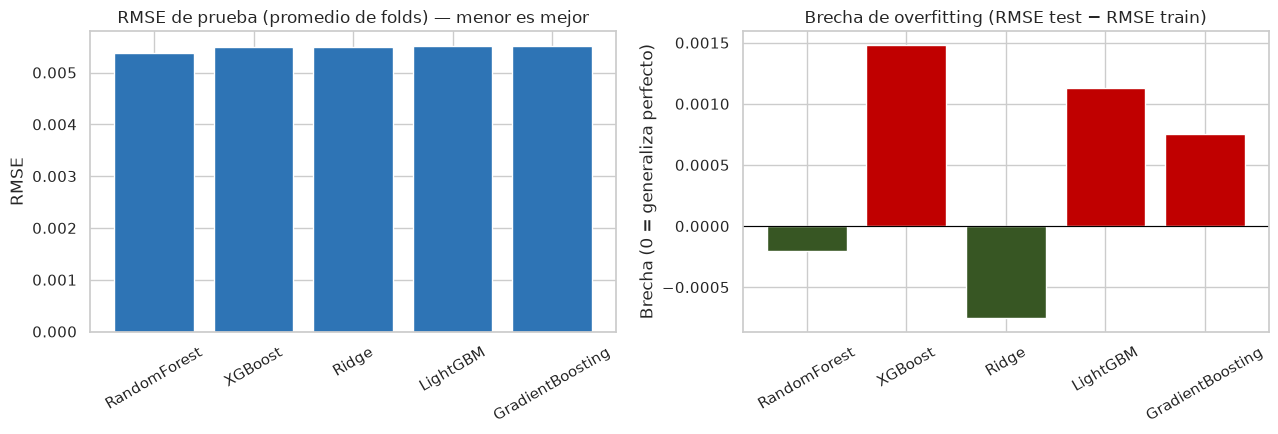

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = summary_df["modelo"]
axes[0].bar(order, summary_df["rmse_test"], color="#2E74B5")
axes[0].set_title("RMSE de prueba (promedio de folds) — menor es mejor")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=30)

colors = ["#C00000" if v > 0 else "#375623" for v in summary_df["brecha_overfitting"]]
axes[1].bar(order, summary_df["brecha_overfitting"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Brecha de overfitting (RMSE test − RMSE train)")
axes[1].set_ylabel("Brecha (0 = generaliza perfecto)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


**Cómo leer estos dos gráficos juntos:** el mejor modelo no es
necesariamente el de menor RMSE si su brecha de overfitting es grande — eso
indica que puede estar ganando por casualidad en este dataset particular,
no porque generalice bien. Un modelo con RMSE ligeramente mayor pero
brecha cercana a cero suele ser la elección más segura para producción.

## 4. Importancia de variables

Tres formas de medirla, deliberadamente distintas, para no confiar en una
sola:

1. **Importancia nativa** de cada modelo (coeficientes de Ridge en valor
   absoluto; `feature_importances_` de los modelos de árboles).
2. **Consenso** — el promedio normalizado entre todos los modelos, para no
   depender del sesgo particular de un solo algoritmo (ej. los modelos de
   árboles tienden a sobrevalorar variables con muchos valores distintos).
3. **Permutation importance** del mejor modelo — la más robusta: mide
   cuánto empeora el error si se desordena aleatoriamente una columna,
   agnóstico a cómo el modelo calcula internamente su importancia.


In [6]:
# Split cronológico simple 80/20 para el análisis de importancia
# (deliberadamente separado del Walk-Forward Validation de arriba: aquí
# necesitamos UN modelo entrenado, no un promedio de varios).
split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

importances = {}
for name, builder in MODEL_BUILDERS.items():
    model = builder()
    model.fit(X_train, y_train)
    if name == "Ridge":
        coefs = model.named_steps["ridge"].coef_
        raw = np.abs(coefs)
    else:
        raw = model.feature_importances_
    importances[name] = raw / raw.sum() if raw.sum() > 0 else raw

imp_df = pd.DataFrame(importances, index=FEATURE_COLS)
imp_df["consenso"] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values("consenso", ascending=False)
imp_df


,Ridge,RandomForest,GradientBoosting,XGBoost,LightGBM,consenso
vol_idx_log_close,0.191516,0.820750,0.646320,0.466814,0.125329,0.450146
main_log_range,0.238939,0.061631,0.097466,0.127736,0.117733,0.128701
main_vol_10d,0.201730,0.037898,0.075140,0.101480,0.077417,0.098733
main_log_return,0.121779,0.009708,0.022589,0.027339,0.093485,0.054980
main_vol_5d,0.037945,0.012252,0.041410,0.076466,0.076541,0.048923
main_upper_wick_log,0.077207,0.011468,0.029741,0.034750,0.087350,0.048103
main_lower_wick_log,0.057878,0.010033,0.022434,0.032552,0.106924,0.045964
vol_idx_log_range,0.015828,0.016209,0.026221,0.035025,0.099912,0.038639
vol_idx_log_return,0.030069,0.010831,0.012122,0.035283,0.099036,0.037468
main_body_log,0.010678,0.007848,0.021306,0.033804,0.081507,0.031029


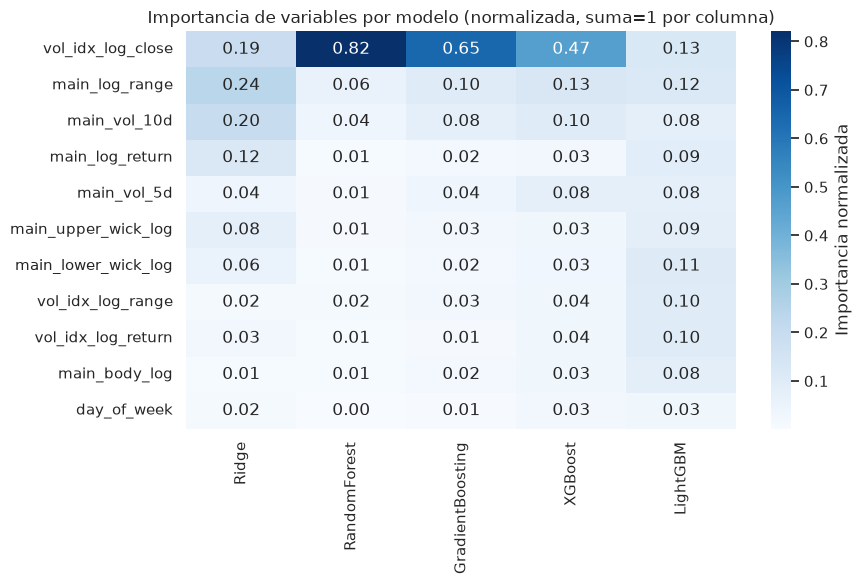

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    imp_df.drop(columns="consenso"), annot=True, fmt=".2f", cmap="Blues",
    cbar_kws={"label": "Importancia normalizada"}, ax=ax,
)
ax.set_title("Importancia de variables por modelo (normalizada, suma=1 por columna)")
plt.tight_layout()
plt.show()


Mejor modelo por RMSE de prueba (Walk-Forward): RandomForest


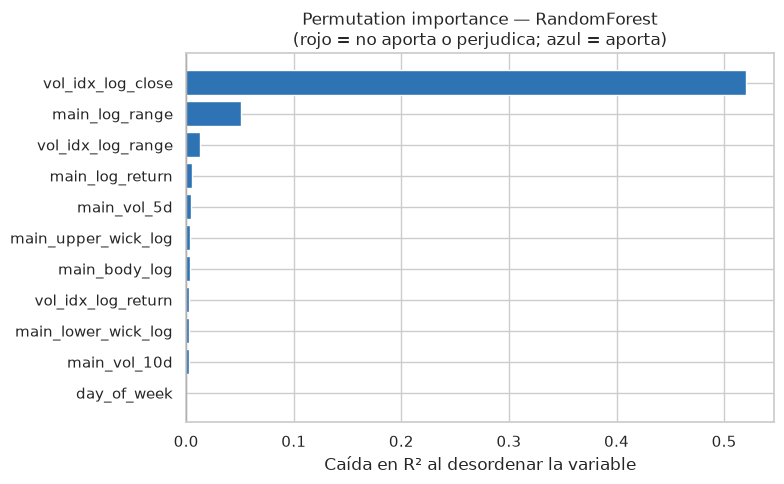

vol_idx_log_close      0.520313
main_log_range         0.051258
vol_idx_log_range      0.012590
main_log_return        0.005003
main_vol_5d            0.004244
main_upper_wick_log    0.003206
main_body_log          0.003173
vol_idx_log_return     0.002667
main_lower_wick_log    0.002508
main_vol_10d           0.002332
day_of_week            0.000002
dtype: float64

In [8]:
best_name = summary_df.iloc[0]["modelo"]
print(f"Mejor modelo por RMSE de prueba (Walk-Forward): {best_name}")

best_model = MODEL_BUILDERS[best_name]()
best_model.fit(X_train, y_train)

perm_result = permutation_importance(
    best_model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1
)
perm_imp = pd.Series(perm_result.importances_mean, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C00000" if v <= 0 else "#2E74B5" for v in perm_imp]
ax.barh(perm_imp.index, perm_imp.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Permutation importance — {best_name}\n(rojo = no aporta o perjudica; azul = aporta)")
ax.set_xlabel("Caída en R² al desordenar la variable")
plt.tight_layout()
plt.show()

perm_imp.sort_values(ascending=False)


## 5. Simplificación: ¿se puede reducir el modelo sin perder desempeño?

Tomamos las variables de **menor consenso** (menos importancia promedio
entre todos los modelos) y las eliminamos, para ver si el modelo reducido
rinde prácticamente igual — en cuyo caso, menos variables = modelo más
simple, más rápido de servir en producción, y menos superficie para
overfitting futuro.


In [18]:
N_TO_DROP = 3  # ajustable: cuántas variables de menor consenso eliminar
bottom_features = imp_df["consenso"].sort_values().index[:N_TO_DROP].tolist()
reduced_cols = [c for c in FEATURE_COLS if c not in bottom_features]

print(f"Variables eliminadas ({N_TO_DROP}): {bottom_features}")
print(f"Variables restantes ({len(reduced_cols)}): {reduced_cols}")

X_train_full, X_test_full = X_train, X_test
X_train_red = df[reduced_cols].values[:split_idx]
X_test_red = df[reduced_cols].values[split_idx:]

model_full = MODEL_BUILDERS[best_name](); model_full.fit(X_train_full, y_train)
model_reduced = MODEL_BUILDERS[best_name](); model_reduced.fit(X_train_red, y_train)

pred_full = model_full.predict(X_test_full)
pred_reduced = model_reduced.predict(X_test_red)

p_full, p_red = X_train_full.shape[1], X_train_red.shape[1]
r2_full, r2_red = r2_score(y_test, pred_full), r2_score(y_test, pred_reduced)

comparison = pd.DataFrame([
    {"version": f"Completo ({p_full} features)", "rmse": rmse(y_test, pred_full),
     "r2": r2_full, "r2_ajustado": adjusted_r2(r2_full, len(y_test), p_full)},
    {"version": f"Reducido ({p_red} features)", "rmse": rmse(y_test, pred_reduced),
     "r2": r2_red, "r2_ajustado": adjusted_r2(r2_red, len(y_test), p_red)},
])
comparison


Variables eliminadas (3): ['day_of_week', 'main_body_log', 'vol_idx_log_return']
Variables restantes (8): ['main_log_return', 'main_log_range', 'main_upper_wick_log', 'main_lower_wick_log', 'main_vol_5d', 'main_vol_10d', 'vol_idx_log_close', 'vol_idx_log_range']


,version,rmse,r2,r2_ajustado
0,Completo (11 features),0.005364,0.507557,0.502499
1,Reducido (8 features),0.005363,0.507652,0.503985


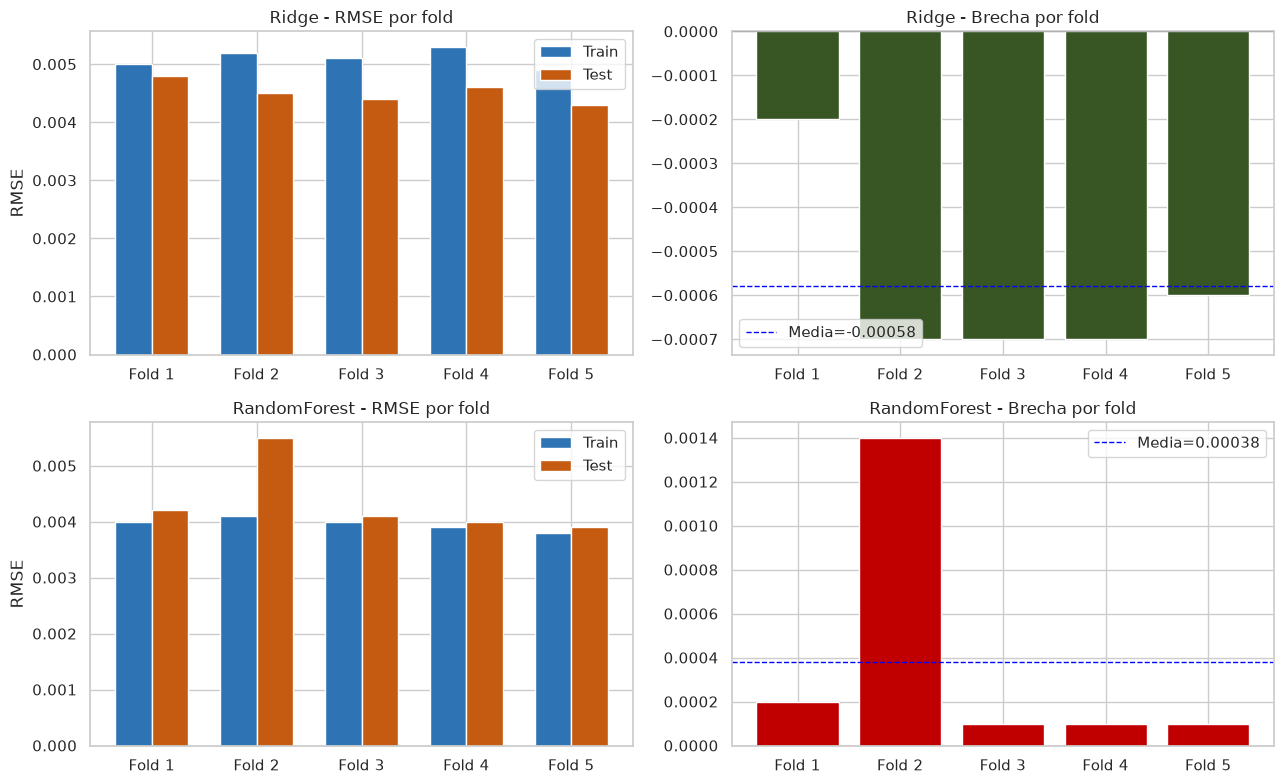

In [20]:
# Asumimos que la variable `fold_details` ya existe en la memoria 
# por haber ejecutado el bloque de código anterior.

modelos_a_revisar = ['Ridge', 'RandomForest']
fig, axes = plt.subplots(len(modelos_a_revisar), 2, figsize=(13, 4 * len(modelos_a_revisar)))

for row, nombre in enumerate(modelos_a_revisar):
    # 1. Convertimos el resultado a DataFrame por si la función devolvió un diccionario
    detalle = pd.DataFrame(fold_details[nombre]).copy()
    
    # 2. Si la función original no generó una columna 'fold', la creamos dinámicamente
    if 'fold' not in detalle.columns:
        detalle['fold'] = range(1, len(detalle) + 1)
        
    # Calculamos la brecha
    detalle['brecha'] = detalle['test_rmse'] - detalle['train_rmse']
    
    # --- Gráfico 1: Comparación Train vs Test RMSE ---
    ax = axes[row, 0]
    width = 0.35
    x = np.arange(len(detalle))
    
    ax.bar(x - width/2, detalle['train_rmse'], width, label='Train', color='#2E74B5')
    ax.bar(x + width/2, detalle['test_rmse'], width, label='Test', color='#C55A11')
    
    ax.set_xticks(x)
    ax.set_xticklabels([f'Fold {f}' for f in detalle['fold']])
    ax.set_ylabel('RMSE')
    ax.set_title(f'{nombre} - RMSE por fold')
    ax.legend()

    # --- Gráfico 2: Brecha de Overfitting ---
    ax2 = axes[row, 1]
    colors = ['#C00000' if v > 0 else '#375623' for v in detalle['brecha']]
    
    ax2.bar([f'Fold {f}' for f in detalle['fold']], detalle['brecha'], color=colors)
    ax2.axhline(0, color='black', linewidth=0.8)
    
    media = detalle['brecha'].mean()
    ax2.axhline(media, color='blue', linestyle='--', linewidth=1, label=f'Media={media:.5f}')
    
    ax2.set_title(f'{nombre} - Brecha por fold')
    ax2.legend()

plt.tight_layout()
plt.show() # Cambiado de savefig a show para que se visualice directamente en tu entorno

**Cómo decidir con la tabla de arriba:** si el RMSE del modelo reducido
es prácticamente igual (o el R² ajustado del reducido es **mayor** — indica
que las variables quitadas realmente no compensaban su costo en grados de
libertad), quédate con el modelo reducido: mismo desempeño, menos
complejidad. Si el RMSE reducido empeora de forma notoria, esas variables sí
aportaban señal real pese a su bajo score de importancia individual
(puede pasar cuando una variable solo importa en combinación con otra).

## 6. Red LSTM

A diferencia de los modelos anteriores (que ven cada día como una fila
independiente), la LSTM ve **secuencias**: los últimos `WINDOW` días de
features consecutivos, para predecir el rango del día siguiente al final
de la ventana. El mecanismo anti-overfitting aquí no son los folds de
Walk-Forward (computacionalmente caro para una red neuronal) sino:

- **Dropout** entre capas LSTM (apaga neuronas aleatoriamente durante el
  entrenamiento, evita que la red dependa de una combinación específica de
  ellas).
- **Early Stopping** sobre la pérdida de validación: detiene el
  entrenamiento en cuanto la red deja de mejorar en datos que no ve durante
  el ajuste de pesos, y restaura los pesos del mejor punto (no los últimos).


In [10]:
WINDOW = 10  # días de historia que ve la red para predecir el día siguiente

def make_sequences(feature_array: np.ndarray, target_array: np.ndarray, window: int):
    """Convierte la matriz de features (filas = días) en secuencias
    superpuestas de `window` días consecutivos, alineadas con el target
    del último día de cada ventana. No introduce data leakage: la
    secuencia que termina en el día t predice el target ya calculado en
    la fila t (target_range_next_day = rango real de t+1)."""
    Xs, ys = [], []
    for i in range(window, len(feature_array)):
        Xs.append(feature_array[i - window:i])
        ys.append(target_array[i - 1])
    return np.array(Xs), np.array(ys)


feat_arr = df[FEATURE_COLS].values
target_arr = df["target_range_next_day"].values
X_seq, y_seq = make_sequences(feat_arr, target_arr, WINDOW)
print(f"Secuencias: X={X_seq.shape}  y={y_seq.shape}")

# Split cronológico train/val/test — nunca aleatorio en series de tiempo.
n = len(X_seq)
i_train, i_val = int(n * 0.70), int(n * 0.85)
X_tr, X_va, X_te = X_seq[:i_train], X_seq[i_train:i_val], X_seq[i_val:]
y_tr, y_va, y_te = y_seq[:i_train], y_seq[i_train:i_val], y_seq[i_val:]
print(f"Train: {len(X_tr)}  Val: {len(X_va)}  Test: {len(X_te)}")

# El escalador se ajusta SOLO con datos de entrenamiento (si se ajustara
# con todo el dataset, el val/test "filtrarían" su distribución al
# entrenamiento — mismo principio de RF03 aplicado al preprocesamiento).
n_features = X_tr.shape[2]
scaler = StandardScaler().fit(X_tr.reshape(-1, n_features))

def scale_sequences(arr):
    shape = arr.shape
    return scaler.transform(arr.reshape(-1, n_features)).reshape(shape)

X_tr_s, X_va_s, X_te_s = scale_sequences(X_tr), scale_sequences(X_va), scale_sequences(X_te)


Secuencias: X=(5401, 10, 11)  y=(5401,)
Train: 3780  Val: 810  Test: 811


In [11]:
lstm_model = keras.Sequential([
    keras.layers.Input(shape=(WINDOW, n_features)),
    keras.layers.LSTM(32, return_sequences=True),
    keras.layers.Dropout(0.2),
    keras.layers.LSTM(16),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1),
])
lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse")
lstm_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

history = lstm_model.fit(
    X_tr_s, y_tr,
    validation_data=(X_va_s, y_va),
    epochs=100, batch_size=32,
    callbacks=[early_stop], verbose=0,
)
print(f"Entrenamiento detenido en la época {len(history.history['loss'])} (early stopping).")


E0000 00:00:1784947220.366831   99756 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 32)         │         5,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,785 (34.32 KB)

 Trainable params: 8,785 (34.32 KB)

 Non-trainable params: 0 (0.00 B)

Entrenamiento detenido en la época 13 (early stopping).


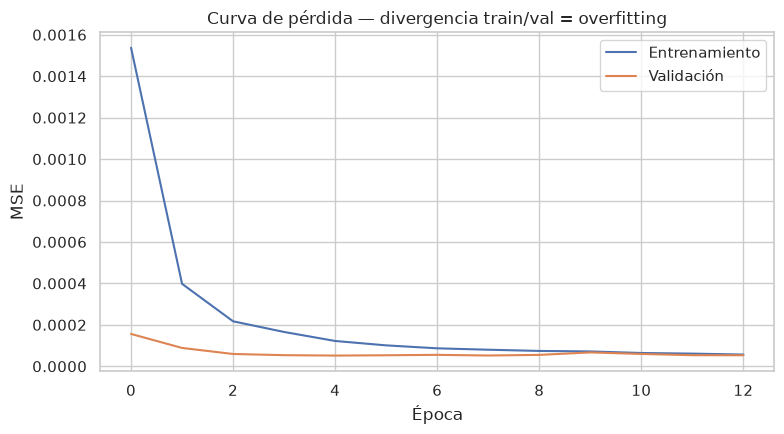

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(history.history["loss"], label="Entrenamiento")
ax.plot(history.history["val_loss"], label="Validación")
ax.set_xlabel("Época")
ax.set_ylabel("MSE")
ax.set_title("Curva de pérdida — divergencia train/val = overfitting")
ax.legend()
plt.tight_layout()
plt.show()


LSTM — RMSE: 0.00559   R²: 0.3637   R² ajustado (aprox.): 0.3550


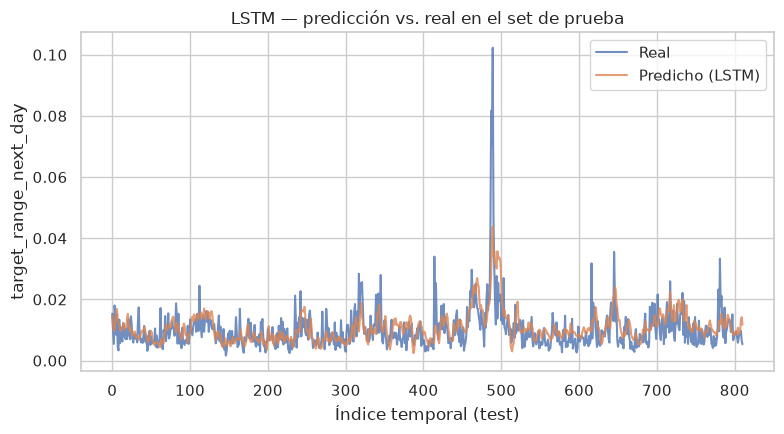

In [13]:
pred_lstm = lstm_model.predict(X_te_s, verbose=0).flatten()

rmse_lstm = rmse(y_te, pred_lstm)
r2_lstm = r2_score(y_te, pred_lstm)
# Nota metodológica: R² ajustado asume un conteo claro de "predictores"
# (válido para modelos lineales/árboles). En una red neuronal el número
# real de parámetros libres es mucho mayor que n_features — se reporta
# aquí usando n_features como aproximación estándar de referencia, no
# como una medida estrictamente equivalente a la de los modelos clásicos.
r2_adj_lstm = adjusted_r2(r2_lstm, len(y_te), n_features)

print(f"LSTM — RMSE: {rmse_lstm:.5f}   R²: {r2_lstm:.4f}   R² ajustado (aprox.): {r2_adj_lstm:.4f}")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(y_te, label="Real", alpha=0.8)
ax.plot(pred_lstm, label="Predicho (LSTM)", alpha=0.8)
ax.set_title("LSTM — predicción vs. real en el set de prueba")
ax.set_xlabel("Índice temporal (test)")
ax.set_ylabel("target_range_next_day")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Comparación final de todos los modelos

In [14]:
final_rows = summary_df[["modelo", "rmse_test", "r2_test", "r2_adj_test", "brecha_overfitting"]].copy()
final_rows.columns = ["modelo", "rmse", "r2", "r2_ajustado", "brecha_overfitting"]
final_rows["metodo_evaluacion"] = "Walk-Forward (promedio 5 folds)"

lstm_row = pd.DataFrame([{
    "modelo": "LSTM",
    "rmse": rmse_lstm,
    "r2": r2_lstm,
    "r2_ajustado": r2_adj_lstm,
    "brecha_overfitting": np.nan,  # no es directamente comparable (ver nota abajo)
    "metodo_evaluacion": "Split cronológico único (train/val/test)",
}])

final_comparison = pd.concat([final_rows, lstm_row], ignore_index=True).sort_values("rmse").reset_index(drop=True)
final_comparison


,modelo,rmse,r2,r2_ajustado,brecha_overfitting,metodo_evaluacion
0,RandomForest,0.005385,0.508057,0.497831,-0.000208,Walk-Forward (promedio 5 folds)
1,XGBoost,0.005487,0.490051,0.479451,0.001481,Walk-Forward (promedio 5 folds)
2,Ridge,0.005494,0.485015,0.474311,-0.000752,Walk-Forward (promedio 5 folds)
3,LightGBM,0.005516,0.484719,0.474008,0.001130,Walk-Forward (promedio 5 folds)
4,GradientBoosting,0.005519,0.481086,0.470299,0.000751,Walk-Forward (promedio 5 folds)
5,LSTM,0.005594,0.363728,0.354968,NaN,Split cronológico único (train/val/test)


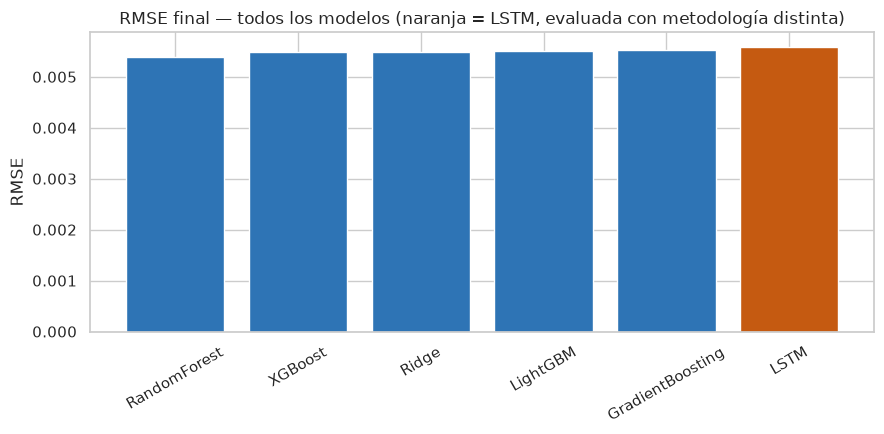

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#2E74B5" if m != "LSTM" else "#C55A11" for m in final_comparison["modelo"]]
ax.bar(final_comparison["modelo"], final_comparison["rmse"], color=colors)
ax.set_title("RMSE final — todos los modelos (naranja = LSTM, evaluada con metodología distinta)")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


**Importante antes de sacar conclusiones:** la fila de LSTM **no es
directamente comparable** en rigor estadístico con las demás — se evaluó
con un único split cronológico, no con el promedio de 5 folds de
Walk-Forward Validation que sí tuvieron los otros cinco modelos. Antes de
preferir la LSTM sobre un modelo clásico solo por esta tabla, sería
necesario correrle también una validación de múltiples ventanas (más caro
computacionalmente, por eso no se hizo por defecto aquí).


## Conclusiones (completar con los resultados reales de tu corrida)

Preguntas para responder mirando las tablas y gráficos de arriba, no antes:

1. **¿Cuál modelo generaliza mejor** (menor RMSE de prueba **y** menor
   brecha de overfitting a la vez, no solo el RMSE más bajo)?
2. **¿Las variables `main_vol_5d`/`main_vol_10d` y `vol_idx_*` dominan la
   importancia**, como sugiere la teoría de volatility clustering? Si una
   variable que la teoría dice que debería importar aparece con importancia
   baja, vale la pena revisar si está bien calculada antes de descartarla.
3. **¿El modelo reducido (sección 5) rinde igual con menos variables?** Si
   sí, ese es el que conviene llevar a producción — menos superficie de
   overfitting futuro y features más baratas de mantener en el Data
   Service.
4. **¿La LSTM justifica su complejidad adicional** (más lenta de entrenar,
   de servir, y de explicar) frente a un modelo de árboles con RMSE
   similar? Si no hay una ganancia clara, un modelo clásico bien
   regularizado suele ser la opción más sostenible para este proyecto.

Con las respuestas a estas 4 preguntas, seguimos con la exportación del
modelo elegido al Model Registry (MLflow) y la implementación del
endpoint `/predict` del ML Service.
